# AB Testing
## Using the T-Test

> **Disclaimer:** This notebook was generated with the assistance of AI and has been human-reviewed for accuracy and quality.

**Topics Covered:**
- T-Test
- Practical applications in AB Testing

## 1. T-Testing

### Key Terms

**P-Value**
The p-value is the probability of observing your results (or more extreme results) assuming the null hypothesis is true. A small p-value (typically < 0.05) means the observed difference is unlikely due to random chance, giving us reason to reject the null hypothesis.

**Null Hypothesis (H₀)**
The null hypothesis is the default assumption that there is *no difference* between the groups being compared. In AB testing: *"Variant A and Variant B perform the same."* We assume this is true until the data tells us otherwise.

**Alternative Hypothesis (H₁)**
The alternative hypothesis is what you are trying to prove — that a *real difference exists*. In AB testing: *"Variant B performs differently (or better) than Variant A."* We accept this only if the p-value is small enough to reject H₀.

---

### Statistical Tests

| Test | When to Use |
|------|-------------|
| **T-Test** | Comparing the means of **two groups** (continuous data, e.g. revenue, time on page) |
| **ANOVA** | Comparing the means of **three or more groups** simultaneously |
| **Chi-Square** | Comparing **proportions or frequencies** between groups (categorical data, e.g. click rate, conversion rate) |

**T-Test** — Tests whether the means of two groups are statistically different. It accounts for sample size and variability, producing a t-statistic that maps to a p-value.

**ANOVA (Analysis of Variance)** — Extends the t-test to multiple groups. Instead of running many pairwise t-tests (which inflates error), ANOVA tests all groups at once to see if at least one mean differs significantly.

**Chi-Square Test** — Used when your outcome is categorical (did the user convert: yes/no?). It compares observed frequencies to expected frequencies to determine if the distribution differs across groups.

---

### Why We Use the T-Test for AB Testing

In a typical AB test, you split users into two groups — a **control (A)** and a **variant (B)** — and measure a continuous metric like revenue per user, session duration, or checkout value. The t-test is the standard choice because:

- You have exactly **two groups** to compare
- Your metric is **continuous and approximately normally distributed** (or your sample is large enough for the Central Limit Theorem to apply)
- You want to know if the **difference in means** is statistically significant, not just due to random variation

The test produces a p-value. If p < 0.05, you conclude the variant had a real effect and it's safe to roll it out.

---

### Practical Business Applications

| Business Question | AB Test Example |
|-------------------|-----------------|
| **E-commerce** | Does a new checkout button color increase average order value? |
| **SaaS / Product** | Does a redesigned onboarding flow improve 7-day retention? |
| **Marketing** | Does subject line A or B generate higher email open rates? |
| **Pricing** | Does showing a monthly vs. annual price first increase subscriptions? |
| **Content / Media** | Does a personalized homepage recommendation increase time on site? |

In each case, the business defines a **success metric**, splits traffic randomly between A and B, collects data, and runs a t-test to determine if the observed difference is statistically significant before making a permanent change. This removes guesswork and grounds product decisions in evidence.

## 2. The Student's T-Test Formula

The t-statistic measures how many standard errors apart the two group means are. The larger the t-value, the less likely the difference is due to chance.

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{s^2 \left(\frac{1}{n_1} + \frac{1}{n_2}\right)}}$$

Where:
- $\bar{x}_1, \bar{x}_2$ — sample means of group 1 and group 2
- $n_1, n_2$ — sample sizes of group 1 and group 2
- $s^2$ — the **pooled variance** (a combined estimate of variance across both groups)

---

### Pooled Variance

The pooled variance $s^2$ combines the spread from both groups into a single estimate, weighted by their degrees of freedom:

$$s^2 = \frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}$$

Where:
- $s_1^2, s_2^2$ — sample variances of group 1 and group 2
- $(n_1 - 1)$ and $(n_2 - 1)$ — degrees of freedom for each group
- $n_1 + n_2 - 2$ — total degrees of freedom

Pooling is valid when we assume both groups share the same underlying population variance (the standard assumption in a two-sample t-test). It gives a more stable variance estimate than using either group alone, especially when sample sizes are unequal.

---

> In the following code blocks, we will implement this t-score from scratch — computing the sample means, sample variances, pooled variance, and final t-statistic manually before comparing against a library result.

In [1]:
# Control group (original website design)
group_a = [5, 4, 5, 6, 3]

# Treatment group (redesigned website)
group_b = [1, 3, 2, 3, 2]

In [2]:
import statistics

In [3]:
# Calculate the variance for each group

variance_a = statistics.variance(group_a)
variance_b = statistics.variance(group_b)

print("Variance of Group A:", variance_a)
print("Variance of Group B:", variance_b)

Variance of Group A: 1.3
Variance of Group B: 0.7


In [4]:
# Get the sample sizes for each group

n_a = len(group_a)
n_b = len(group_b)

print("Sample size of Group A:", n_a)
print("Sample size of Group B:", n_b)

Sample size of Group A: 5
Sample size of Group B: 5


In [5]:
# Calculate the numerator of the pooled variance formula
# Each group's variance is weighted by its degrees of freedom (n - 1)

numerator = ( (n_a - 1) * variance_a ) + ( (n_b - 1) * variance_b )

print("Pooled variance numerator:", numerator)

Pooled variance numerator: 8.0


In [6]:
# Calculate the denominator of the pooled variance formula
# This is the total degrees of freedom across both groups

denominator = n_a + n_b - 2

print("Pooled variance denominator:", denominator)

Pooled variance denominator: 8


In [7]:
# Divide numerator by denominator to get the pooled variance

pooled_variance = numerator / denominator

print("Pooled Variance:", pooled_variance)

Pooled Variance: 1.0


In [ ]:
# Calculate the t-score
# Numerator: difference of means
# Denominator: sqrt(pooled_variance * harmonic term (1/n_a + 1/n_b))

mean_a = statistics.mean(group_a)
mean_b = statistics.mean(group_b)

t_score = (mean_a - mean_b) / (pooled_variance * (1/n_a + 1/n_b)) ** 0.5

print("Mean of Group A:", mean_a)
print("Mean of Group B:", mean_b)
print("T-Score:", t_score)

## 3. Interpreting the T-Score

A t-score by itself is **meaningless** — knowing that our t-score is 3.79 tells us nothing on its own. A number without context is just a number.

To make sense of it, we need to ask: *how unusual is this t-score?* To answer that, we look at the **t-distribution**.

---

### The T-Distribution

The t-distribution is a bell-shaped curve that represents the **probabilities of all possible t-scores** we could observe if the null hypothesis were true (i.e., if there were truly no difference between the two groups). Every possible t-score has a corresponding probability — most t-scores cluster near zero, and extreme values become increasingly rare in the tails.

By placing our calculated t-score on this distribution, we can see exactly how likely or unlikely it is to occur by chance alone. A t-score that falls far out in the tail of the distribution signals that such a result would be very improbable under the null hypothesis — giving us evidence to reject it.

> In the next step, we will use the t-distribution to find the **p-value**: the probability of observing a t-score at least as extreme as ours, assuming no real difference exists.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Degrees of freedom for our dataset: n_a + n_b - 2
df = n_a + n_b - 2

# Because of the Central Limit Theorem, even with small samples, the sampling
# distribution of the t-statistic follows a t-distribution with `df` degrees of freedom.
# As sample size grows, this converges to the standard normal distribution.

x = np.linspace(-5, 5, 500)
y = stats.t.pdf(x, df)

# Critical value for two-tailed test at alpha = 0.05
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha / 2, df)

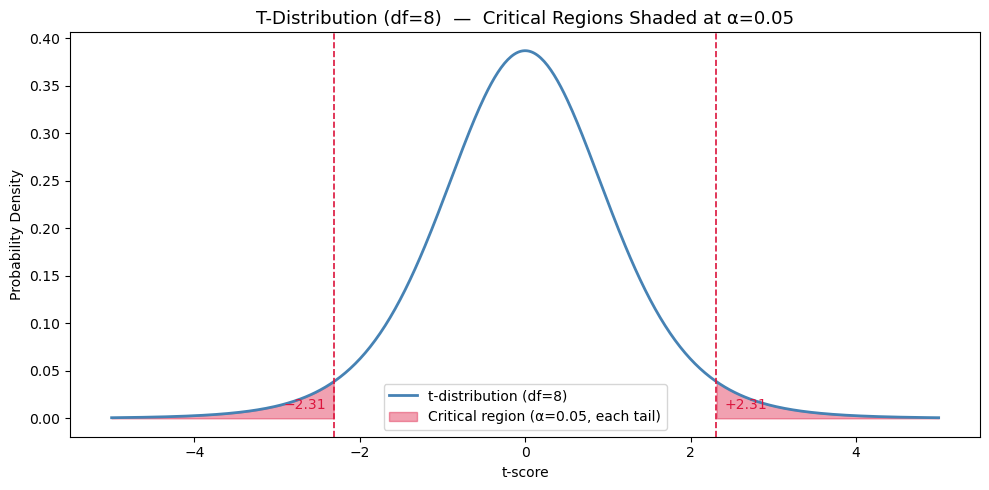

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

# Full distribution
ax.plot(x, y, color="steelblue", linewidth=2, label=f"t-distribution (df={df})")

# Shade critical regions (tails)
ax.fill_between(x, y, where=(x <= -t_critical), color="crimson", alpha=0.4, label=f"Critical region (α=0.05, each tail)")
ax.fill_between(x, y, where=(x >= t_critical), color="crimson", alpha=0.4)

# Mark critical boundaries
ax.axvline(-t_critical, color="crimson", linestyle="--", linewidth=1.2)
ax.axvline( t_critical, color="crimson", linestyle="--", linewidth=1.2)
ax.text(-t_critical - 0.1, 0.01, f"−{t_critical:.2f}", ha="right", color="crimson", fontsize=10)
ax.text( t_critical + 0.1, 0.01, f"+{t_critical:.2f}", ha="left",  color="crimson", fontsize=10)

ax.set_title(f"T-Distribution (df={df})  —  Critical Regions Shaded at α=0.05", fontsize=13)
ax.set_xlabel("t-score")
ax.set_ylabel("Probability Density")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
print("Degrees of freedom :", df)
print("Critical t-value   : ±", t_critical)
print("Any |t| >", t_critical, "falls in the critical region → reject H₀")

Degrees of freedom : 8
Critical t-value   : ± 2.306004135204166
Any |t| > 2.306004135204166 falls in the critical region → reject H₀


## 4. What Does This Mean in Practice?

Our t-score of **~3.79** clearly falls inside the critical region (beyond ±2.306). This means the difference between Group A and Group B is statistically significant — it is extremely unlikely to have occurred by random chance alone. We reject the null hypothesis.

---

### Direction of the Change

The sign of the t-score tells us the **direction**. Because we computed `mean_a - mean_b`:

- **Group A (control):** mean = 4.6
- **Group B (treatment — redesigned website):** mean = 2.2

The result is a **positive t-score**, which means Group A scored *higher* than Group B. In other words, the redesign caused a **negative change** — performance got worse, not better.

---

### Why Might This Have Happened?

There are several practical explanations for why the redesigned website underperformed:

| Possible Cause | Explanation |
|----------------|-------------|
| **Change aversion** | Users are familiar with the original design. Any change — even an objectively better one — can cause friction and lower engagement in the short term. |
| **Usability regression** | The redesign may have moved or removed elements users relied on (navigation, CTAs, search), making the site harder to use. |
| **Visual overload** | A new design might introduce more elements, choices, or unfamiliar layouts that increase cognitive load and reduce conversion. |
| **Audience mismatch** | The redesign may have been optimized for a different user persona than the one actually tested. |

> **Takeaway:** A statistically significant result does not always mean improvement. The direction matters just as much as the significance. In this case, the data is telling us clearly — **do not ship the redesign.** Roll back to the control and investigate what specifically drove the drop.

## 5. The Easy Way — `scipy.stats.ttest_ind`

Everything we just computed manually — the sample means, variances, pooled variance, and final t-score — can be done in a **single line** using SciPy's `stats.ttest_ind` function.

`ttest_ind` stands for *independent samples t-test*, which is exactly what we performed: two separate, unrelated groups measured on the same metric. Pass it the two lists and it returns both the **t-statistic** and the **p-value** directly — no manual arithmetic required.

The p-value is the probability of observing a t-score at least this extreme if the null hypothesis were true. A p-value below **0.05** confirms that the result is statistically significant and we can safely reject H₀.

In [3]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(group_a, group_b)

print("T-Score :", t_stat)
print("P-Value :", p_value)

T-Score : -5.7021444095227904
P-Value : 2.0859515569064334e-05


---

## 6. Exercises — Running the T-Test & Interpreting Results

For each scenario below, sample data for two groups has been provided. Complete all **four tasks**:

1. **Run `ttest_ind`** on the two groups and print the t-score and p-value
2. **Write your interpretation** — is the result significant? What does it mean for the business?

### Exercise 1 — E-Commerce Checkout Flow

An e-commerce company redesigned its checkout flow. The data below represents the number of items purchased per session for the original (A) and redesigned (B) checkout flows.

**Interpretation:** *(write here — is p < 0.05? What does this mean for the business?)*

In [ ]:
group_a = [3, 2, 4, 3, 5, 2, 3, 4, 2, 3]   # original checkout
group_b = [5, 6, 4, 7, 5, 6, 5, 7, 6, 5]   # redesigned checkout

#H0: the redesign of the

### Exercise 2 — Customer Satisfaction Score

A telecom company rolled out a new customer service training program. NPS scores were collected from customers who interacted with untrained (A) vs. trained (B) agents.

**Interpretation:** *(write here — is p < 0.05? What does this mean for the business?)*

In [ ]:
group_a = [38, 42, 40, 35, 44, 39, 41, 37, 43, 40]   # untrained agents
group_b = [48, 51, 46, 50, 53, 47, 49, 52, 48, 50]   # trained agents

### Exercise 3 — Restaurant Ticket Size

A casual dining chain rolled out an upselling training program for its staff. The data represents the total spend per table (in dollars) before (A) and after (B) the training.

In [ ]:
group_a = [17.50, 19.00, 18.00, 18.75, 17.25, 19.50, 18.50, 17.75, 19.25, 18.00]   # before training
group_b = [20.50, 21.00, 19.75, 20.25, 21.50, 20.00, 19.50, 21.25, 20.75, 20.00]   # after training

### Exercise 4 — Warehouse Processing Time

A logistics company deployed new warehouse management software. Processing times (in minutes) were recorded for workers using the old (A) vs. new (B) system.

In [ ]:
group_a = [8.5, 9.0, 8.2, 8.8, 9.1, 8.4, 8.7, 9.2, 8.3, 8.6]   # old system
group_b = [7.8, 7.5, 8.0, 7.6, 7.9, 7.4, 8.1, 7.7, 7.5, 7.8]   # new system

### Exercise 5 — Online Ad Click-Through Rate

A digital marketing team tested a new ad creative against the original. The data represents the number of clicks per 100 impressions in each session for the original (A) and new (B) creative.

In [ ]:
group_a = [3, 4, 3, 5, 3, 4, 2, 4, 3, 4]   # original creative
group_b = [2, 3, 2, 2, 3, 2, 1, 3, 2, 2]   # new creative